# Practical Task: Supervised Learning

Predict median house value from census attributes, using the same setup as the Boston Housing lecture example: numeric inputs, a continuous target, ordinary least squares, and a scatter plot with the fitted line drawn through the observations.

I used the California Housing dataset (Pace and Barry, 1997): 20,640 block groups from the 1990 US Census. sklearn documents this table as the replacement for Boston Housing. I downloaded the StatLib archive from Figshare (`data/cal_housing.tgz`) and wrote the prepared table to `data/california_housing.csv`.

Boston Housing predicted median value from average rooms. The California analogue of that feature, `AveRooms`, correlates only 0.15 with price. Median income (`MedInc`) correlates 0.69, so that is the feature I plot and the one-feature model I train. The eight-feature model is the same estimator with the rest of the columns included.


## 1. Features (X) and target (y)

| Variable | Role | Meaning |
|---|---|---|
| `MedInc` | input | median income in the block group, in tens of thousands of USD |
| `HouseAge` | input | median house age, years |
| `AveRooms` | input | average rooms per household |
| `AveBedrms` | input | average bedrooms per household |
| `Population` | input | block-group population |
| `AveOccup` | input | average household size |
| `Latitude`, `Longitude` | input | block-group location |
| `MedHouseVal` | **target** | median house value, in units of $100,000 |

Task type: **regression**. The target is continuous, so the lecture's linear model applies directly.


## 2. Load the dataset and prepare the table


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("data/california_housing.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BLUE = "#0072B2"
VERMILLION = "#D55E00"
GREEN = "#009E73"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.frameon": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
    }
)

def save_and_show(fig, stem: str) -> None:
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(png_path)
    fig.savefig(FIG_DIR / f"{stem}.pdf")
    display(Image(filename=str(png_path)))
    plt.close(fig)


df = pd.read_csv(DATA_PATH)
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print()
df.describe().T[["count", "mean", "std", "min", "max"]].round(3)


Rows: 20,640
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Missing values: 0



,count,mean,std,min,max
MedInc,20640.0,3.871,1.900,0.500,15.000
HouseAge,20640.0,28.639,12.586,1.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,141.909
AveBedrms,20640.0,1.097,0.474,0.333,34.067
Population,20640.0,1425.477,1132.462,3.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,1243.333
Latitude,20640.0,35.632,2.136,32.540,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,5.000


There are no missing values, so no imputation. Two measurement details matter for later plots:

- `MedHouseVal` is stored in units of $100,000. The maximum is 5.0, which is a $500,000 cap (992 block groups, 4.8% of the table). Boston Housing had the same kind of cap at $50,000.
- `AveRooms` reaches 142 and `AveOccup` reaches 1,243. Those rows stay in the table. Removing them would tidy the rooms scatter without changing the income model much, and I did not pre-register a filter.


In [3]:
n_capped = int((df["MedHouseVal"] >= 5.0).sum())
print(f"Block groups at the $500,000 cap: {n_capped} ({100 * n_capped / len(df):.2f}%)")

feature_cols = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
]
target_col = "MedHouseVal"

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Correlation with MedHouseVal:")
print(df[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False).round(3))


Block groups at the $500,000 cap: 992 (4.81%)
X shape: (20640, 8)
y shape: (20640,)

Correlation with MedHouseVal:
MedHouseVal    1.000
MedInc         0.688
AveRooms       0.152
HouseAge       0.106
AveOccup      -0.024
Population    -0.025
Longitude     -0.046
AveBedrms     -0.047
Latitude      -0.144
Name: MedHouseVal, dtype: float64


## 3. Relationship between input and target

The left panel is the Boston-style view: one numeric input against the continuous target. The right panel is the rooms feature that played that role in the lecture. Each panel shows a random 4,000-point sample so the cloud is readable; the models below use all 20,640 rows. Income is the clearer linear pattern, so it is the feature I take into the one-feature model.


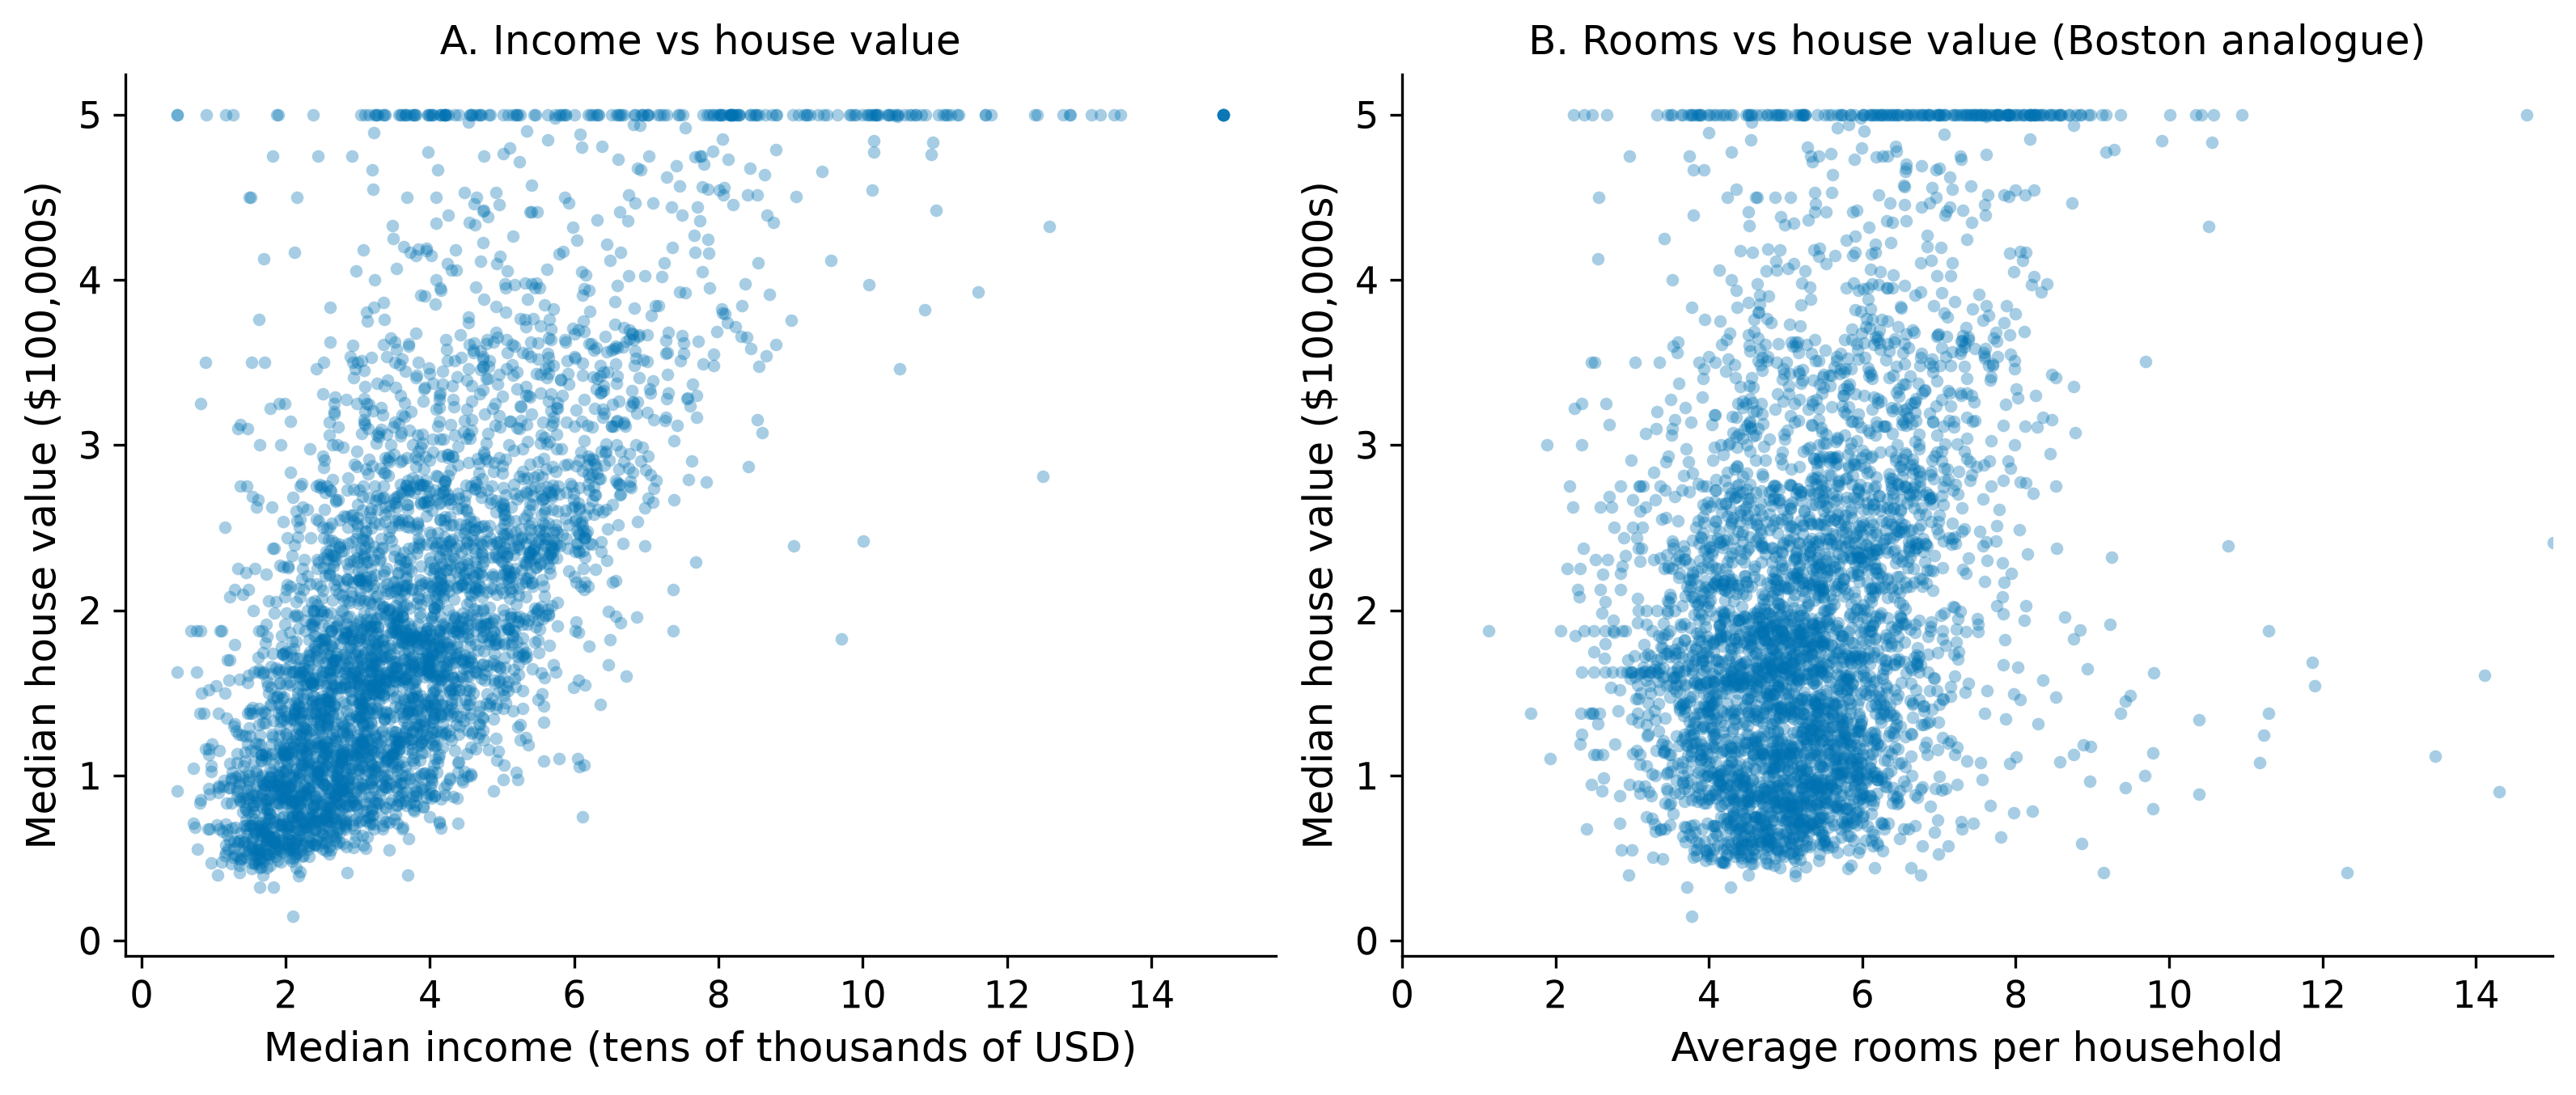

In [4]:
rng = np.random.default_rng(42)
# 20,640 points overplot; a 4,000-point sample keeps the cloud readable.
# The fitted models below still use the full table.
sample_idx = rng.choice(len(df), size=4000, replace=False)
sample = df.iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), constrained_layout=True)

axes[0].scatter(
    sample["MedInc"],
    sample["MedHouseVal"],
    s=14,
    alpha=0.35,
    c=BLUE,
    linewidths=0,
    rasterized=True,
)
axes[0].set_xlabel("Median income (tens of thousands of USD)")
axes[0].set_ylabel("Median house value ($100,000s)")
axes[0].set_title("A. Income vs house value")

axes[1].scatter(
    sample["AveRooms"],
    sample["MedHouseVal"],
    s=14,
    alpha=0.35,
    c=BLUE,
    linewidths=0,
    rasterized=True,
)
axes[1].set_xlim(0, 15)
axes[1].set_xlabel("Average rooms per household")
axes[1].set_ylabel("Median house value ($100,000s)")
axes[1].set_title("B. Rooms vs house value (Boston analogue)")

save_and_show(fig, "01_feature_target_scatter")


Panel A rises with income, then hits the $500,000 ceiling. The cloud widens as income grows: the same income is compatible with a wide range of prices. Panel B, restricted to a readable rooms range, is almost a vertical smear. That is why a rooms-only line, the Boston lecture's usual choice, is a poor one-feature model on this table.


## 4. Train a linear regression

Ordinary least squares, the same class of model as the lecture. I hold out 20% of the block groups and fit only on the remaining 80%. The split is random with `random_state=42` so the numbers below are reproducible.

The one-feature model uses `MedInc` alone, matching the lecture's single-x scatter. The eight-feature model is still `LinearRegression`, with `StandardScaler` inside a `Pipeline` so population and latitude are not on incomparable scales.


In [5]:
X_income = df[["MedInc"]]

X_train, X_test, y_train, y_test = train_test_split(
    X_income, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Training block groups: {len(X_train):,}")
print(f"Test block groups:     {len(X_test):,}")
print()
print("Fitted one-feature model:")
print(
    f"MedHouseVal = {model.intercept_:.3f} + {model.coef_[0]:.3f} × MedInc"
)
print()
print(
    "In dollars: each extra $10,000 of median income is associated with "
    f"${model.coef_[0] * 100_000:,.0f} higher median house value."
)


Training block groups: 16,512
Test block groups:     4,128

Fitted one-feature model:
MedHouseVal = 0.445 + 0.419 × MedInc

In dollars: each extra $10,000 of median income is associated with $41,934 higher median house value.


## 5. Predictions, plotted on the original data

This is the Boston Housing figure: observed points, and the OLS line through them. The points are the held-out test block groups. The line is the model fitted on the training split.


In [6]:
y_pred = model.predict(X_test)

pred_table = pd.DataFrame(
    {
        "MedInc": X_test["MedInc"].to_numpy(),
        "observed_MedHouseVal": y_test.to_numpy(),
        "predicted_MedHouseVal": y_pred,
    }
)
pred_table.head(8)


,MedInc,observed_MedHouseVal,predicted_MedHouseVal
0,1.6812,0.47700,1.149589
1,2.5313,0.45800,1.506069
2,3.4801,5.00001,1.903937
3,5.7376,2.18600,2.850594
4,3.7250,2.78000,2.006633
5,4.7147,1.58700,2.421652
6,5.0839,1.98200,2.576472
7,3.6908,1.57500,1.992292


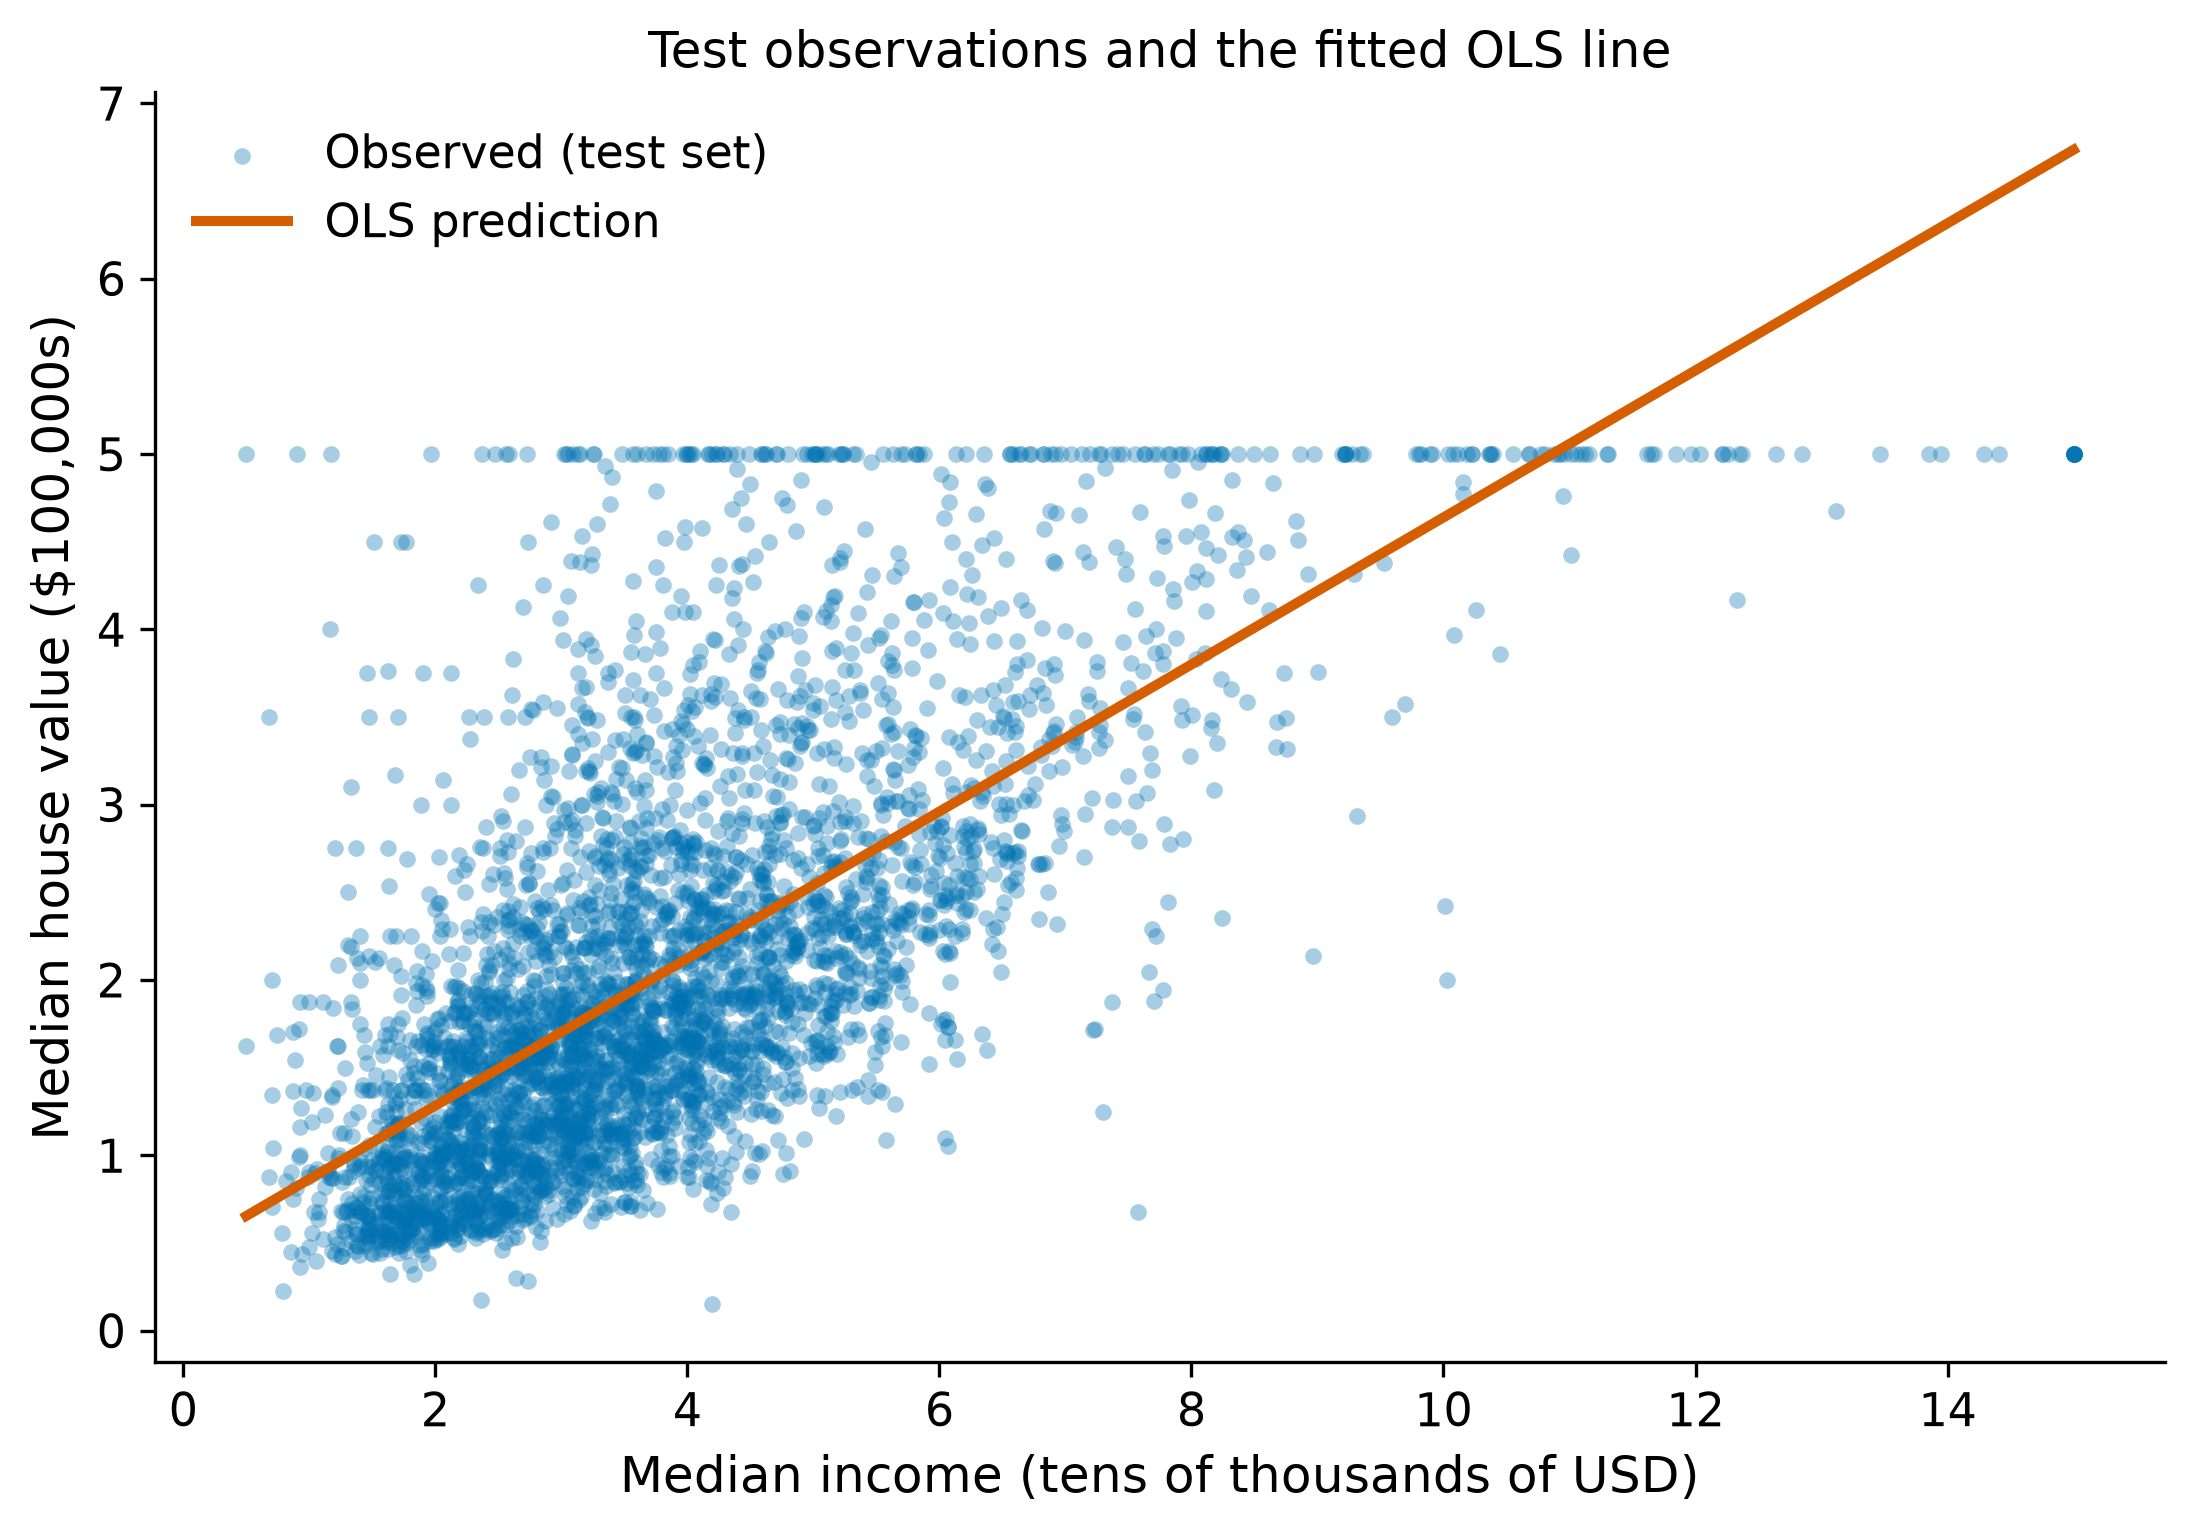

In [7]:
x_line = pd.DataFrame(
    {
        "MedInc": np.linspace(
            X_test["MedInc"].min(), X_test["MedInc"].max(), 200
        )
    }
)
y_line = model.predict(x_line)

fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)
ax.scatter(
    X_test["MedInc"],
    y_test,
    s=16,
    alpha=0.35,
    c=BLUE,
    linewidths=0,
    rasterized=True,
    label="Observed (test set)",
)
ax.plot(
    x_line["MedInc"],
    y_line,
    color=VERMILLION,
    linewidth=2.4,
    label="OLS prediction",
)
ax.set_xlabel("Median income (tens of thousands of USD)")
ax.set_ylabel("Median house value ($100,000s)")
ax.set_title("Test observations and the fitted OLS line")
ax.legend(loc="upper left")
save_and_show(fig, "02_ols_predictions")


## 6. Evaluation

For regression the useful scores are RMSE (typical size of the residual, in the target's units), MAE (same, less sensitive to large misses), and R² (fraction of variance matched on the test set). Accuracy is a classification metric and does not apply here.


In [8]:
def regression_report(y_true, y_hat, label):
    mse = mean_squared_error(y_true, y_hat)
    rmse = root_mean_squared_error(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)
    r2 = r2_score(y_true, y_hat)
    return {
        "model": label,
        "n_test": int(len(y_true)),
        "MSE": mse,
        "RMSE": rmse,
        "RMSE_$": rmse * 100_000,
        "MAE": mae,
        "MAE_$": mae * 100_000,
        "R2": r2,
    }


one_feature_scores = regression_report(y_test, y_pred, "OLS, MedInc only")
pd.DataFrame([one_feature_scores]).round(3)


,model,n_test,MSE,RMSE,RMSE_$,MAE,MAE_$,R2
0,"OLS, MedInc only",4128,0.709,0.842,84209.012,0.63,62990.865,0.459


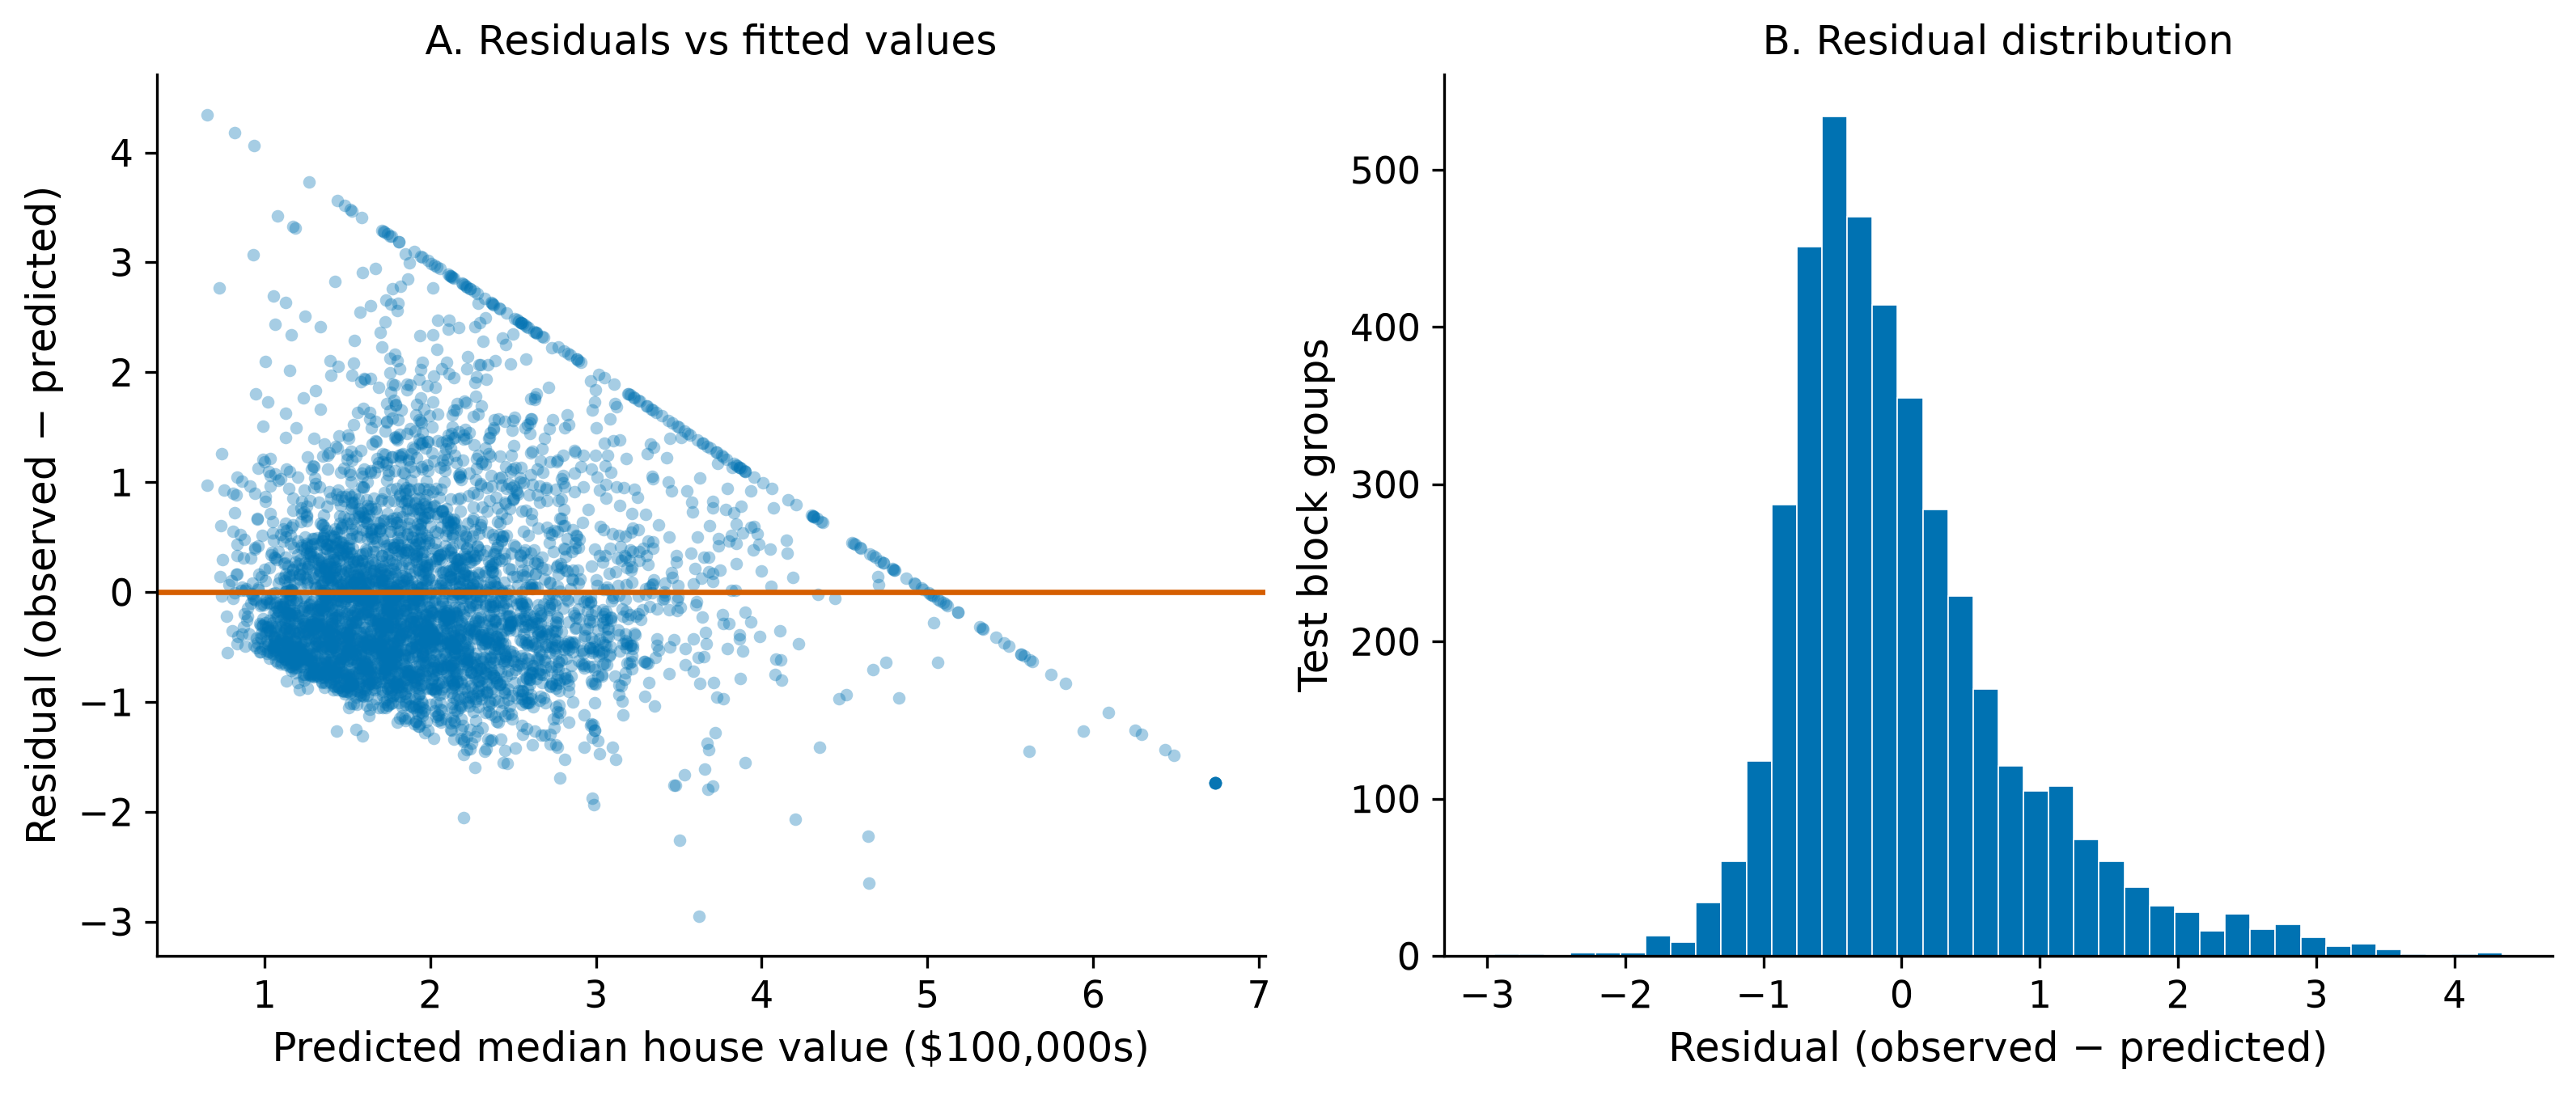

Mean residual:   0.0042
Median residual: -0.1776
Residual std:    0.8421


In [9]:
residuals = y_test.to_numpy() - y_pred

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), constrained_layout=True)

axes[0].scatter(
    y_pred,
    residuals,
    s=14,
    alpha=0.35,
    c=BLUE,
    linewidths=0,
    rasterized=True,
)
axes[0].axhline(0.0, color=VERMILLION, linewidth=1.6)
axes[0].set_xlabel("Predicted median house value ($100,000s)")
axes[0].set_ylabel("Residual (observed − predicted)")
axes[0].set_title("A. Residuals vs fitted values")

axes[1].hist(residuals, bins=40, color=BLUE, edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Residual (observed − predicted)")
axes[1].set_ylabel("Test block groups")
axes[1].set_title("B. Residual distribution")

save_and_show(fig, "03_residuals")

print(f"Mean residual:   {residuals.mean():.4f}")
print(f"Median residual: {np.median(residuals):.4f}")
print(f"Residual std:    {residuals.std():.4f}")


The residual plot fans out as predicted value rises, and a stripe of positive residuals sits at the $500,000 cap. OLS assumes constant residual variance; that assumption does not hold here. The line is still a fair summary of the average trend. It is a poor description of the expensive tail.


## 7. Same estimator, all eight features

The lecture plot uses one x-variable so the line can be drawn in 2D. The same `LinearRegression` can take the rest of the table. Scaling goes inside the pipeline and is fit on the training split only.


In [10]:
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    df[feature_cols], y, test_size=0.2, random_state=42
)

full_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("ols", LinearRegression()),
    ]
)
full_model.fit(X_full_train, y_full_train)
y_full_pred = full_model.predict(X_full_test)

full_scores = regression_report(y_full_test, y_full_pred, "OLS, eight features")

# Rooms-only model, for the Boston comparison.
X_rooms_train, X_rooms_test, y_rooms_train, y_rooms_test = train_test_split(
    df[["AveRooms"]], y, test_size=0.2, random_state=42
)
rooms_model = LinearRegression().fit(X_rooms_train, y_rooms_train)
rooms_scores = regression_report(
    y_rooms_test, rooms_model.predict(X_rooms_test), "OLS, AveRooms only"
)

scores = pd.DataFrame([rooms_scores, one_feature_scores, full_scores])
scores.round(3)


,model,n_test,MSE,RMSE,RMSE_$,MAE,MAE_$,R2
0,"OLS, AveRooms only",4128,1.292,1.137,113680.757,0.889,88914.904,0.014
1,"OLS, MedInc only",4128,0.709,0.842,84209.012,0.630,62990.865,0.459
2,"OLS, eight features",4128,0.556,0.746,74558.138,0.533,53320.013,0.576


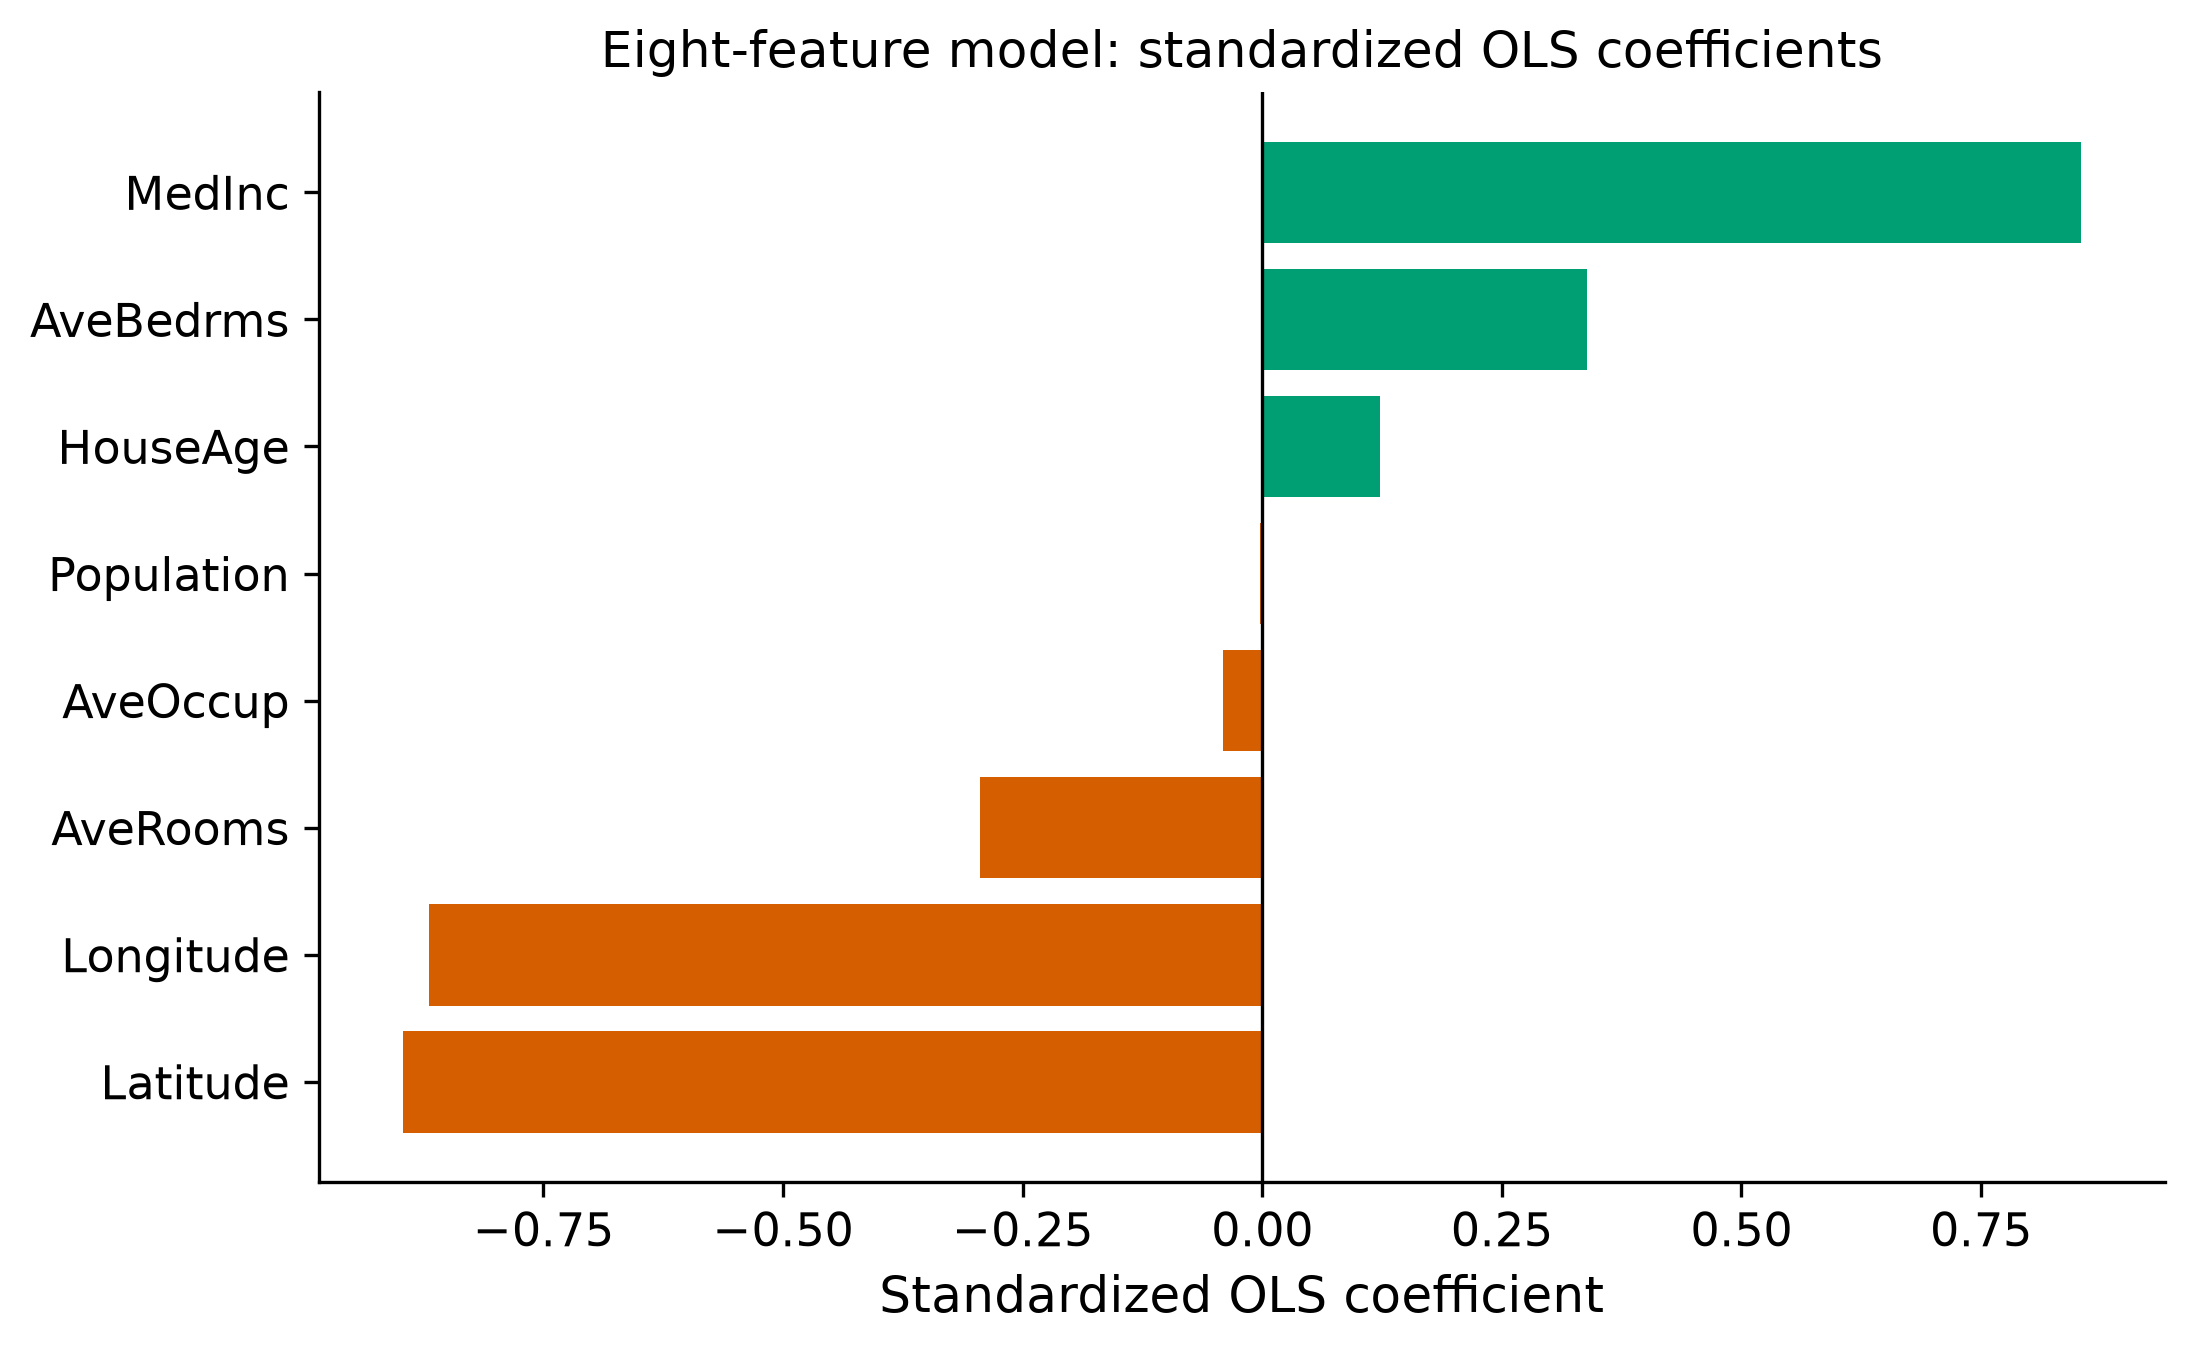

,feature,standardized_coefficient
6,Latitude,-0.897
7,Longitude,-0.870
2,AveRooms,-0.294
5,AveOccup,-0.041
4,Population,-0.002
1,HouseAge,0.123
3,AveBedrms,0.339
0,MedInc,0.854


In [11]:
ols = full_model.named_steps["ols"]
coef_table = pd.DataFrame(
    {"feature": feature_cols, "standardized_coefficient": ols.coef_}
).sort_values("standardized_coefficient")

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
colors = [VERMILLION if c < 0 else GREEN for c in coef_table["standardized_coefficient"]]
ax.barh(coef_table["feature"], coef_table["standardized_coefficient"], color=colors)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized OLS coefficient")
ax.set_title("Eight-feature model: standardized OLS coefficients")
save_and_show(fig, "04_coefficients")

coef_table.round(3)


## 8. What the model learned

The one-feature fit is

\[
\mathrm{MedHouseVal} = 0.445 + 0.419 \times \mathrm{MedInc}.
\]

A $10,000 increase in block-group median income is associated with a $41,900 increase in median house value. On 4,128 held-out block groups that line explains 45.9% of the variance (R² = 0.459). RMSE is 0.842 units, about $84,200. MAE is $63,000. The mean test value is $205,500, so a typical miss is roughly 30% of that mean.

The scatter around the line is wide, and it widens at higher incomes. 992 block groups (4.8%) sit at the $500,000 cap. OLS has no upper bound, so the fitted line keeps rising past $500,000 for high-income block groups even though no observation can. `AveRooms`, the Boston lecture's usual x-variable, gives test R² = 0.014 on this table. Rooms are not the main price signal in 1990 California census data.

The eight-feature linear model reaches test R² = 0.576 and RMSE of about $74,600. After scaling, latitude, longitude, and income dominate the coefficients. `AveRooms` turns negative once bedrooms and income are in the model; that is collinearity, not a claim that extra rooms lower price. The coefficients describe a linear association in 1990 census geography, not what would happen if income changed. The one-feature figure does what the lecture figure did: a positive slope through a noisy cloud. Income is the feature that line actually tracks.

**Source.** Pace, R. Kelley, and Ronald Barry. "Sparse Spatial Autoregressions." *Statistics & Probability Letters* 33 (1997): 291–297. Archive: https://ndownloader.figshare.com/files/5976036
